In [2]:
import pandas as pd 
import folium 

# 1. Create a dataframe with the actual coordinates for the target oncology centers 
data = {
    'Hospital': ['CHOP', "Penn Medicine (HUP)", 'Jefferson Center City', 'Temple Main Campus','Jefferson Einstein','Veterans Affairs Medical Center', 'Fox Chase Cancer Center'],
    'Latitude': [39.948704, 39.950202, 39.949101, 40.005356,40.037087,39.947437,40.07097],
    'Longitude': [-75.193923, -75.193686, -75.15818, -75.150974,-75.142161,-75.199619,-75.09103]
}
hospitals_df = pd.DataFrame(data)

# 2. Initialize a Folium map centered on Philadelphia
philly_map = folium.Map(location=[39.9526, -75.1652], zoom_start = 12, tiles='cartodbpositron')

# 3. Iterate throught the dataframe and add markers for each Hospital
for index, row in hospitals_df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['Hospital'],
        tooltip=f"Click for {row['Hospital']}",
        icon=folium.Icon(color='red', icon='plus-sign')
    ).add_to(philly_map)

philly_map

In [3]:
import os
import pandas as pd
from dotenv import load_dotenv, find_dotenv
from census import Census

# 1. Find and load the file
env_path = find_dotenv()
load_dotenv(env_path, override=True)

# 2. Get the key and STRIP any hidden whitespace or newlines
api_key = os.getenv('CENSUS_API_KEY')
if api_key:
    api_key = api_key.strip()

# 3. Debug print to verify length
if api_key:
    print(f"Success! Key loaded: {api_key[:4]}...{api_key[-4:]} | Length: {len(api_key)}")
else:
    print("FAILED: File found, but the key inside is empty.")

# 4. Initialize the Census API client
c = Census(api_key)

# 5. Fetch ACS 5-Year Estimate Variables for Philadelphia County (FIPS 101) in PA (FIPS 42)
census_data = c.acs5.state_county_tract(
    fields=('NAME', 'B01003_001E', 'B19013_001E', 'B02001_003E', 'B03002_012E'),
    state_fips='42',
    county_fips='101',
    tract='*'
)

# 6. Convert to DataFrame and clean
tract_df = pd.DataFrame(census_data)
tract_df = tract_df.rename(columns={
    'B01003_001E': 'Total_Population',
    'B19013_001E': 'Median_Income',
    'B02001_003E': 'Black_Population',
    'B03002_012E': 'Hispanic_Population'
})

tract_df['Median_Income'] = tract_df['Median_Income'].apply(lambda x: None if x is not None and x < 0 else x)
tract_df['Pct_Black'] = (tract_df['Black_Population'] / tract_df['Total_Population']).fillna(0) * 100
tract_df['Pct_Hispanic'] = (tract_df['Hispanic_Population'] / tract_df['Total_Population']).fillna(0) * 100
tract_df['GEOID'] = tract_df['state'] + tract_df['county'] + tract_df['tract']

tract_df.head()

Success! Key loaded: 2621...0ccf | Length: 40


,NAME,Total_Population,Median_Income,Black_Population,Hispanic_Population,state,county,tract,Pct_Black,Pct_Hispanic,GEOID
0,Census Tract 1.01; Philadelphia County; Pennsy...,1963.0,111148.0,52.0,223.0,42,101,000101,2.649007,11.360163,42101000101
1,Census Tract 1.02; Philadelphia County; Pennsy...,3172.0,101033.0,76.0,104.0,42,101,000102,2.395965,3.278689,42101000102
2,Census Tract 2; Philadelphia County; Pennsylvania,3103.0,102670.0,379.0,112.0,42,101,000200,12.213986,3.609410,42101000200
3,Census Tract 3; Philadelphia County; Pennsylvania,4727.0,102104.0,624.0,274.0,42,101,000300,13.200762,5.796488,42101000300
4,Census Tract 4.01; Philadelphia County; Pennsy...,2919.0,92182.0,630.0,156.0,42,101,000401,21.582734,5.344296,42101000401


In [4]:
import geopandas as gpd 
import pandas as pd 
import folium

print("Downloading shapefiles from Census Bureau...")
url = "https://www2.census.gov/geo/tiger/TIGER2022/TRACT/tl_2022_42_tract.zip"
pa_tracts = gpd.read_file(url)

philly_tracts = pa_tracts[pa_tracts["COUNTYFP"] == '101'].copy()

philly_geo_df = philly_tracts.merge(tract_df, on='GEOID', how='inner')
print(f"Successfully merged! Total tracts mapped: {len(philly_geo_df)}")

philly_map = folium.Map(location=[39.9526, -75.1652], zoom_start=12, tiles='cartodbpositron')

folium.Choropleth(
    geo_data=philly_geo_df,
    name='Median Household Income',
    data=philly_geo_df,
    columns=["GEOID", "Median_Income"],
    key_on = 'feature.properties.GEOID',
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Median Household Income ($)',
    nan_fill_color='white'
).add_to(philly_map)

hospitals_data = {
    'Hospital': ['CHOP', "Penn Medicine (HUP)", 'Jefferson Center City', 'Temple Main Campus','Jefferson Einstein','Veterans Affairs Medical Center', 'Fox Chase Cancer Center'],
    'Latitude': [39.948704, 39.950202, 39.949101, 40.005356,40.037087,39.947437,40.07097],
    'Longitude': [-75.193923, -75.193686, -75.15818, -75.150974,-75.142161,-75.199619,-75.09103]
}
hospitals_df = pd.DataFrame(hospitals_data)

for index, row in hospitals_df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['Hospital'],
        tooltip=f"Click for {row['Hospital']}",
        icon=folium.Icon(color='red', icon='plus-sign')
    ).add_to(philly_map)

folium.LayerControl().add_to(philly_map)

philly_map.save("project1_map.html")

Successfully merged! Total tracts mapped: 408


Network downloaded. Plotting graph.


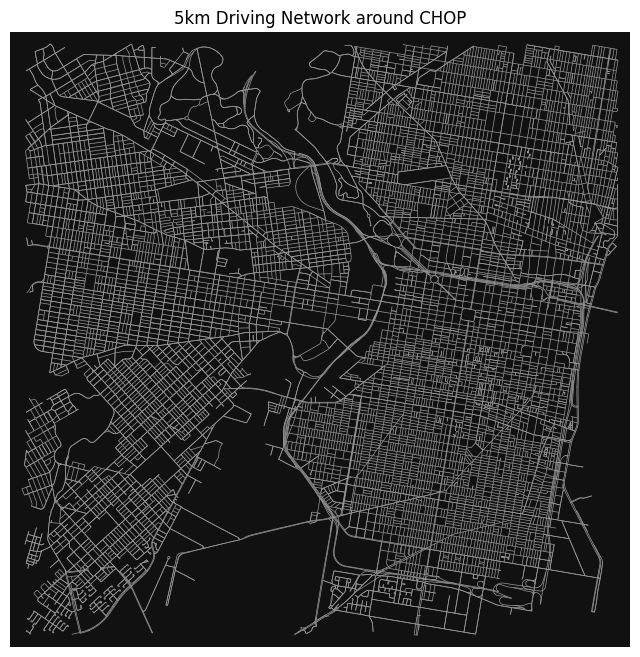

In [5]:
import osmnx as ox 
import matplotlib.pyplot as plt 

chop_coords = (39.948704, -75.192923)

print('Downloading street network... this may take 1-2 minutes.')
G = ox.graph_from_point(chop_coords, dist=5000, network_type='drive')

G_proj = ox.project_graph(G)

print("Network downloaded. Plotting graph.")
fig, ax = ox.plot_graph(
    G_proj,
    node_size=0,
    edge_color='#999999',
    edge_linewidth=0.5,
    show=False,
    close=False,
    figsize=(8,8)
)
plt.title("5km Driving Network around CHOP")
plt.show()

In [6]:
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point
import folium
import osmnx as ox

print("Calculating edge speeds and travel times...")
# 1. Add edge speeds and calculate travel times on the projected graph
# OSMNX automatically estimates speeds based on road types if speed limits are missing
G_proj = ox.add_edge_speeds(G_proj)
G_proj = ox.add_edge_travel_times(G_proj)

# 2. Find the center node closest to CHOP in the network
# CHOP coords: (39.948704, -75.193923) -> X is longitude, Y is latitude.
center_node = ox.distance.nearest_nodes(G, X=-75.193923, Y=39.948704)

# 3. Calculate 15-minute (900 sec) and 30-minute (1800 sec) travel bubbles
trip_times = [900, 600] # We calculate the largest first so it renders underneath the smaller one
colors = ['#ff9999', '#ff3333'] # Light red for 30 min, dark red for 15 min
isochrone_polys = []

print("Building isochrone polygons...")
for trip_time in trip_times:
    # Create a subgraph of all nodes reachable within the trip_time
    subgraph = nx.ego_graph(G_proj, center_node, radius=trip_time, distance='travel_time')
    
    # Extract the (x, y) coordinates of these reachable nodes
    node_points = [Point((data['x'], data['y'])) for node, data in subgraph.nodes(data=True)]
    
    # Wrap them in a convex hull to create a solid polygon shape
    bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
    isochrone_polys.append(bounding_poly)

# 4. Convert our polygons into a GeoDataFrame for mapping
gdf_isochrones = gpd.GeoDataFrame(geometry=isochrone_polys, crs=G_proj.graph['crs'])

# Project back to standard GPS coordinates (EPSG:4326) for Folium
gdf_isochrones = gdf_isochrones.to_crs(epsg=4326)
gdf_isochrones['Time'] = ['30 Minutes', '15 Minutes']
gdf_isochrones['Color'] = colors

# 5. Create a new map centered on CHOP to display the results
chop_map = folium.Map(location=[39.948704, -75.193923], zoom_start=13, tiles='cartodbpositron')

# 6. Add the isochrone polygons to the map
for _, row in gdf_isochrones.iterrows():
    folium.GeoJson(
        row['geometry'],
        style_function=lambda x, color=row['Color']: {
            'fillColor': color,
            'color': color,
            'weight': 1,
            'fillOpacity': 0.4
        },
        tooltip=f"Drive Time: {row['Time']}"
    ).add_to(chop_map)

# Add the CHOP marker
folium.Marker(
    location=[39.948704, -75.193923],
    popup='CHOP',
    icon=folium.Icon(color='red', icon='plus-sign')
).add_to(chop_map)

# Display the map (Use the .save("chop_isochrones.html") trick if it doesn't render in Codespaces!)
print("Done! Rendering map...")
chop_map.save("chop_isochrones.html")


Calculating edge speeds and travel times...
Building isochrone polygons...


/tmp/ipykernel_91075/567775195.py:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


Done! Rendering map...


/tmp/ipykernel_91075/567775195.py:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


In [9]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import folium

print("1. Initializing the base map...")
final_map = folium.Map(location=[39.9526, -75.1652], zoom_start=12, tiles='cartodbpositron')

print("2. Adding Census demographic layer...")
# Add the Choropleth layer
folium.Choropleth(
    geo_data=philly_geo_df,
    name='Median Household Income',
    data=philly_geo_df,
    columns=['GEOID', 'Median_Income'],
    key_on='feature.properties.GEOID',
    fill_color='YlGnBu',
    fill_opacity=0.6,
    line_opacity=0.2,
    legend_name='Median Household Income ($)',
    nan_fill_color='white'
).add_to(final_map)

hospitals_data = {
    'Hospital': ['CHOP', 'Penn Medicine (HUP)', 'Jefferson Center City', 'Temple Main Campus', 'Jefferson Einstein', 'Veterans Affairs Medical Center'],
    'Latitude': [39.948704, 39.950202, 39.949101, 40.005356, 40.037087, 39.947437],
    'Longitude': [-75.193923, -75.193686, -75.15818, -75.150974, -75.142161, -75.199619]
}
hospitals_df = pd.DataFrame(hospitals_data)

print("3. Downloading regional street network (This will take 2-3 minutes)...")
# Download a massive 15km network centered on Center City ONCE
G = ox.graph_from_point((39.9526, -75.1652), dist=15000, network_type='drive')
G_proj = ox.project_graph(G)
G_proj = ox.add_edge_speeds(G_proj)
G_proj = ox.add_edge_travel_times(G_proj)

# CHANGED BACK: Set travel times to 15 minutes (900s) and 10 minutes (600s)
trip_times = [900, 600] 
colors = ['#ff9999', '#ff3333']

print("4. Processing 15 & 30 min drive-time networks for all hospitals...")
for index, row in hospitals_df.iterrows():
    hosp_name = row['Hospital']
    lat = row['Latitude']
    lon = row['Longitude']
    
    print(f"   -> Calculating isochrones for {hosp_name}...")
    
    # Find the closest network node to the hospital in our massive regional graph
    center_node = ox.distance.nearest_nodes(G, X=lon, Y=lat)
    
    isochrone_polys = []
    isochrone_times = []
    isochrone_colors = []
    
    for i, trip_time in enumerate(trip_times):
        subgraph = nx.ego_graph(G_proj, center_node, radius=trip_time, distance='travel_time')
        node_points = [Point((data['x'], data['y'])) for node, data in subgraph.nodes(data=True)]
        
        if len(node_points) > 2:
            bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
            isochrone_polys.append(bounding_poly)
            isochrone_times.append(f"{int(trip_time/60)} Minutes")
            isochrone_colors.append(colors[i])
            
    if isochrone_polys:
        gdf_isochrones = gpd.GeoDataFrame(geometry=isochrone_polys, crs=G_proj.graph['crs'])
        gdf_isochrones = gdf_isochrones.to_crs(epsg=4326)
        gdf_isochrones['Time'] = isochrone_times
        gdf_isochrones['Color'] = isochrone_colors
        
        for _, iso_row in gdf_isochrones.iterrows():
            folium.GeoJson(
                iso_row['geometry'],
                style_function=lambda x, color=iso_row['Color']: {
                    'fillColor': color,
                    'color': color,
                    'weight': 2,         # INCREASED from 1 to 2 for a crisp, visible border
                    'fillOpacity': 0.10  # DROPPED from 0.4 to 0.10 to prevent the solid blob effect
                },
                tooltip=f"{hosp_name} - Drive Time: {iso_row['Time']}"
            ).add_to(final_map)
            
    folium.Marker(
        location=[lat, lon],
        popup=hosp_name,
        tooltip=f"Click for {hosp_name}",
        icon=folium.Icon(color='red', icon='plus-sign')
    ).add_to(final_map)

folium.LayerControl().add_to(final_map)
final_map.save("index.html")
print("\nDone! Full 10/15 map saved directly to 'index.html'.")

1. Initializing the base map...
2. Adding Census demographic layer...
3. Downloading regional street network (This will take 2-3 minutes)...
4. Processing 15 & 30 min drive-time networks for all hospitals...
   -> Calculating isochrones for CHOP...


/tmp/ipykernel_91075/2883527288.py:64: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
/tmp/ipykernel_91075/2883527288.py:64: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


   -> Calculating isochrones for Penn Medicine (HUP)...


/tmp/ipykernel_91075/2883527288.py:64: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
/tmp/ipykernel_91075/2883527288.py:64: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


   -> Calculating isochrones for Jefferson Center City...


...

/tmp/ipykernel_91075/2883527288.py:64: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
/tmp/ipykernel_91075/2883527288.py:64: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


   -> Calculating isochrones for Veterans Affairs Medical Center...


/tmp/ipykernel_91075/2883527288.py:64: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull



Done! Full 10/15 map saved directly to 'index.html'.


/tmp/ipykernel_91075/2883527288.py:64: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


In [11]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import folium

print("1. Initializing the base map...")
final_map = folium.Map(location=[39.9526, -75.1652], zoom_start=12, tiles='cartodbpositron')

print("2. Adding Census demographic layer...")
# Add the Choropleth layer
folium.Choropleth(
    geo_data=philly_geo_df,
    name='Median Household Income',
    data=philly_geo_df,
    columns=['GEOID', 'Median_Income'],
    key_on='feature.properties.GEOID',
    fill_color='YlGnBu',
    fill_opacity=0.6,
    line_opacity=0.2,
    legend_name='Median Household Income ($)',
    nan_fill_color='white'
).add_to(final_map)

hospitals_data = {
    'Hospital': ['CHOP', 'Penn Medicine (HUP)', 'Jefferson Center City', 'Temple Main Campus', 'Jefferson Einstein', 'Veterans Affairs Medical Center'],
    'Latitude': [39.948704, 39.950202, 39.949101, 40.005356, 40.037087, 39.947437],
    'Longitude': [-75.193923, -75.193686, -75.15818, -75.150974, -75.142161, -75.199619]
}
hospitals_df = pd.DataFrame(hospitals_data)

trip_times = [1800, 900] 
colors = ['#ff9999', '#ff3333']

print("3. Processing 15 & 30 min walk-time networks for all hospitals...")
for index, row in hospitals_df.iterrows():
    hosp_name = row['Hospital']
    lat = row['Latitude']
    lon = row['Longitude']
    
    print(f"   -> Downloading 3km walk network for {hosp_name}...")
    
    # Download a small, 3km pedestrian network around EACH hospital
    G = ox.graph_from_point((lat, lon), dist=3000, network_type='walk')
    G_proj = ox.project_graph(G)
    
    # THE BULLETPROOF FIX: Manually calculate walk time for EVERY edge, ignoring car speed limits
    # 4.5 km/h = 1.25 meters per second
    walk_speed_ms = 1.25
    for u, v, key, data in G_proj.edges(keys=True, data=True):
        # Time (seconds) = Distance (meters) / Speed (meters per second)
        data['travel_time'] = data['length'] / walk_speed_ms
    
    # Find the closest network node to the hospital
    center_node = ox.distance.nearest_nodes(G, X=lon, Y=lat)
    
    isochrone_polys = []
    isochrone_times = []
    isochrone_colors = []
    
    for i, trip_time in enumerate(trip_times):
        subgraph = nx.ego_graph(G_proj, center_node, radius=trip_time, distance='travel_time')
        node_points = [Point((data['x'], data['y'])) for node, data in subgraph.nodes(data=True)]
        
        if len(node_points) > 2:
            bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
            isochrone_polys.append(bounding_poly)
            isochrone_times.append(f"{int(trip_time/60)} Minutes")
            isochrone_colors.append(colors[i])
            
    if isochrone_polys:
        gdf_isochrones = gpd.GeoDataFrame(geometry=isochrone_polys, crs=G_proj.graph['crs'])
        gdf_isochrones = gdf_isochrones.to_crs(epsg=4326)
        gdf_isochrones['Time'] = isochrone_times
        gdf_isochrones['Color'] = isochrone_colors
        
        for _, iso_row in gdf_isochrones.iterrows():
            folium.GeoJson(
                iso_row['geometry'],
                style_function=lambda x, color=iso_row['Color']: {
                    'fillColor': color,
                    'color': color,
                    'weight': 2,         # INCREASED from 1 to 2 for a crisp, visible border
                    'fillOpacity': 0.10  # DROPPED from 0.4 to 0.10 to prevent the solid blob effect
                },
                tooltip=f"{hosp_name} - Walking Time: {iso_row['Time']}"
            ).add_to(final_map)
            
    folium.Marker(
        location=[lat, lon],
        popup=hosp_name,
        tooltip=f"Click for {hosp_name}",
        icon=folium.Icon(color='red', icon='plus-sign')
    ).add_to(final_map)

folium.LayerControl().add_to(final_map)
final_map.save("index2.html")
print("\nDone! Full 15/30 map saved directly to 'index2.html'.")

1. Initializing the base map...
2. Adding Census demographic layer...
3. Processing 15 & 30 min walk-time networks for all hospitals...
   -> Downloading 3km walk network for CHOP...


/tmp/ipykernel_91075/1885483990.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
/tmp/ipykernel_91075/1885483990.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


   -> Downloading 3km walk network for Penn Medicine (HUP)...


/tmp/ipykernel_91075/1885483990.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
/tmp/ipykernel_91075/1885483990.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


   -> Downloading 3km walk network for Jefferson Center City...


...

   -> Downloading 3km walk network for Jefferson Einstein...


/tmp/ipykernel_91075/1885483990.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
/tmp/ipykernel_91075/1885483990.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull


   -> Downloading 3km walk network for Veterans Affairs Medical Center...


/tmp/ipykernel_91075/1885483990.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull
/tmp/ipykernel_91075/1885483990.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bounding_poly = gpd.GeoSeries(node_points).unary_union.convex_hull



Done! Full 15/30 map saved directly to 'index2.html'.
